<a href="https://colab.research.google.com/github/0XimMena/MASDFR_20271/blob/main/clases/clase_02/sesion2_severidad_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📉 Sesión 2 — Severidad: el primer ladrillo del pricing
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro
### Facultad de Ciencias, UNAM

---

**Tema 1.1:** Severidad en el seguro de daños · **Herramienta:** Python  
**Proyecto:** Nota técnica del producto — módulo de severidad

---

> **Objetivo:** ver la *familia* de distribuciones de severidad y su cola, ajustarlas a datos por
> máxima verosimilitud, comparar con AIC, medir **qué cambia en la cola** (VaR, TVaR, prima) y
> asomarnos al enfoque bayesiano.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las celdas de Ejercicio las completas tú**:
> ahí está el chiste, que practiques por tu cuenta, no solo verme correr código.

## Contenido

1. [Verificación del entorno](#1)
2. [La severidad como variable aleatoria](#2)
3. [Los datos y su forma](#3)
4. [El lenguaje de la cola](#4)
5. [La familia de distribuciones](#5)
6. [Ajuste por máxima verosimilitud y AIC](#6)
7. [Diagnóstico de la cola](#7)
8. [Qué cambia en la cola: VaR, TVaR y prima](#8)
9. [Vistazo bayesiano](#9)
10. [Cierre → Práctica A1](#10)

---

---
<a id='1'></a>
## 1. Verificación del entorno

In [1]:
# ─── Verificación del entorno ──────────────────────────────────────────────
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4.2)

print("✓ Entorno listo")
print(f"  Python {sys.version[:6]} · NumPy {np.__version__} · SciPy {__import__('scipy').__version__}")

✓ Entorno listo
  Python 3.13.1 · NumPy 2.1.3 · SciPy 1.16.3


---
<a id='2'></a>
## 2. La severidad como variable aleatoria

Cada siniestro tiene un **monto** $X \ge 0$. La prima pura nace de dos piezas:

$$\text{Prima pura} = \underbrace{E[N]}_{\text{frecuencia}}\times\underbrace{E[X]}_{\text{severidad}}$$

Hoy modelamos $E[X]$. Primero, la intuición con indicadores de cartera.

In [ ]:
# ─── Indicadores de cartera ────────────────────────────────────────────────
polizas, siniestros, monto_total = 8_500, 374, 12_450_000

frecuencia = siniestros / polizas
severidad  = monto_total / siniestros
prima_pura = frecuencia * severidad

print(f"Frecuencia          : {frecuencia:.4f} sin/póliza")
print(f"Severidad promedio  : ${severidad:,.0f}")
print(f"Prima pura          : ${prima_pura:,.0f}")
print("\n¿Basta el promedio? No: dos carteras con la misma media pueden tener")
print("riesgos muy distintos. Lo que manda es la FORMA de la distribución.")

Frecuencia          : 0.0440 sin/póliza
Severidad promedio  : $33,289
Prima pura          : $1,465

¿Basta el promedio? No: dos carteras con la misma media pueden tener
riesgos muy distintos. Lo que manda es la FORMA de la distribución.


---
<a id='3'></a>
## 3. Los datos y su forma

Usamos una muestra de **severidades** (montos, en miles de MXN). Para que el notebook corra sin
descargas la generamos de forma controlada; **en clase se cambia por los datos reales de tu ramo.**

In [3]:
# ─── Muestra de severidades (miles de MXN) ─────────────────────────────────
cuerpo = stats.lognorm(s=0.9, scale=180).rvs(1_800)
cola   = stats.lognorm(s=0.6, scale=1_500).rvs(200)     # siniestros grandes
sev = pd.Series(np.concatenate([cuerpo, cola]), name="monto_miles")
sev = sev[sev > 0]
x   = sev.values

print(sev.describe().round(1).to_string())

count    2000.0
mean      433.1
std       665.0
min         9.7
25%       109.6
50%       212.5
75%       440.0
max      9856.3


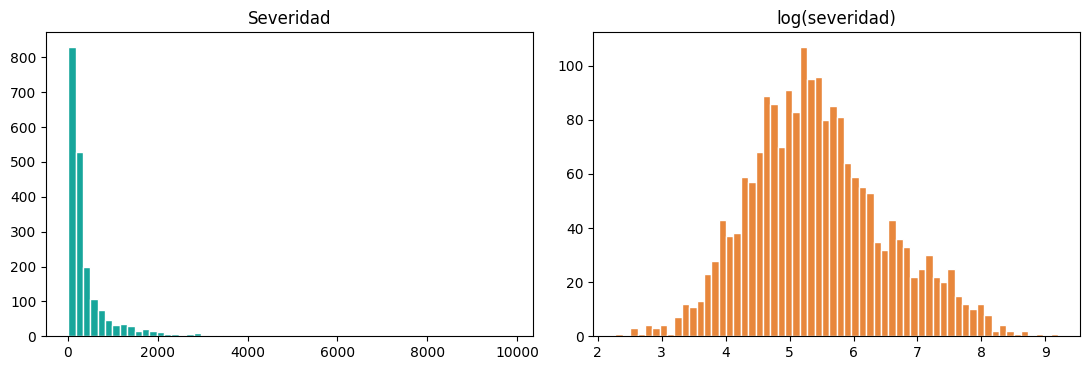

Sesgo=4.73   Media=433   Mediana=213


In [4]:
# ─── La forma: escala natural vs. log ──────────────────────────────────────
from scipy.stats import skew, kurtosis
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(sev, bins=60, color="#17A69B", edgecolor="white"); ax[0].set_title("Severidad")
ax[1].hist(np.log(sev), bins=60, color="#E8873C", edgecolor="white"); ax[1].set_title("log(severidad)")
plt.tight_layout(); plt.show()
print(f"Sesgo={skew(x):.2f}   Media={x.mean():,.0f}   Mediana={np.median(x):,.0f}")

### ✏️ Ejercicio 1 — ¿qué tan sesgada está?

1. Calcula la razón **media / mediana** de `sev`.
2. Calcula el **coeficiente de variación** $CV=\sigma/\mu$.
3. En un comentario, di qué te dicen esos dos números sobre la cola.

In [16]:
# Tu código aquí 👇
#1. Calcula la razón media/mediana de sev.
razon= sev.mean()/sev.median()
#2.Calcula el CV.
cv=sev.std()/sev.mean()
print(f"Razón media/mediana : {razon: .4f}")
print(f"Coeficiente de variación CV: {cv: .4f}")
# Pista: sev.mean(), sev.median(), sev.std()
#Comentario
print("Dado que la razón media/mediana es mayor a 1 y el CV mayor a 1 podemos confirmar que la distribución de la severidad tiene una cola derecha pesada.")
print("En el caso de la razón media/mediana > 1 implica que hay un fuertee sesgo hacia la derecha debido a siniestros extremos.")
print("En el caso del CV > 1 implica que hay alta volatilidad e incertidumbre por lo cual podemos interpretar que pocos siniestros grandes distorsionan el promedio")
print("Como el CV>1 entonces tenemos un riesgo no uniforme. ")


Razón media/mediana :  2.0378
Coeficiente de variación CV:  1.5354
Dado que la razón media/mediana es mayor a 1 y el CV mayor a 1 podemos confirmar que la distribución de la severidad tiene una cola derecha pesada.
En el caso de la razón media/mediana > 1 implica que hay un fuertee sesgo hacia la derecha debido a siniestros extremos.
En el caso del CV > 1 implica que hay alta volatilidad e incertidumbre por lo cual podemos interpretar que pocos siniestros grandes distorsionan el promedio
Como el CV>1 entonces tenemos un riesgo no uniforme. 


---
<a id='4'></a>
## 4. El lenguaje de la cola

Para los siniestros grandes miramos la **función de supervivencia** $S(x)=P(X>x)=1-F(x)$.
La calculamos empíricamente y la vemos en escala log-log (donde la cola se aprecia mejor).

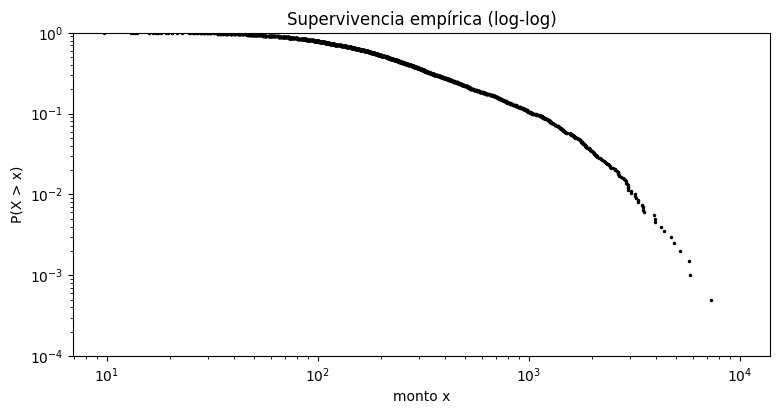

In [7]:
# ─── Supervivencia empírica S(x)=P(X>x) ────────────────────────────────────
xs = np.sort(x)
S_emp = 1.0 - np.arange(1, len(xs) + 1) / len(xs)
plt.plot(xs, S_emp, ".", ms=3, color="black")
plt.xscale("log"); plt.yscale("log"); plt.ylim(1e-4, 1)
plt.title("Supervivencia empírica (log-log)"); plt.xlabel("monto x"); plt.ylabel("P(X > x)")
plt.show()

### ✏️ Ejercicio 2 — leer la cola

1. Estima empíricamente $P(X>500)$ y $P(X>1000)$ (proporción de la muestra que supera el umbral).
2. ¿Cuántas veces más raro es un siniestro de 1000 que uno de 500?

In [12]:
# Tu código aquí 👇
#1
p_500 = (x > 500).mean()
p_1000 = (x > 1000).mean()
print(f"P(X>500)={p_500:.4f}")
print(f"P(X>1000)={p_1000:.4f}")
#2
raro = p_500/p_1000
print(f"Un siniestro mayor de 1000 es {raro: .4f} veces más raro que uno mayor de 500")
# Pista: (x > 500).mean()


P(X>500)=0.2215
P(X>1000)=0.1055
Un siniestro mayor de 1000 es  2.0995 veces más raro que uno mayor de 500


---
<a id='5'></a>
## 5. La familia de distribuciones

Antes de ajustar, **veamos** las cinco candidatas y por qué se ordenan de cola ligera a cola
pesada: Exponencial → Gamma → Lognormal → Weibull → Pareto.

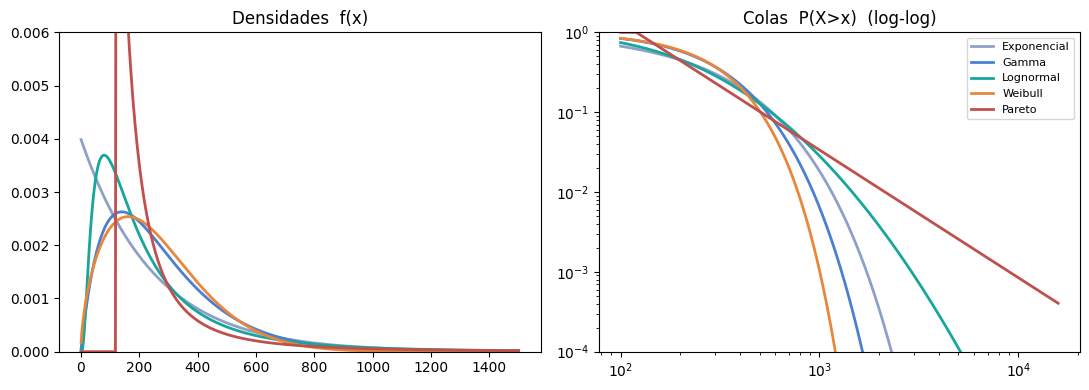

La recta de Pareto en log-log = cola pesada (ley de potencias).


In [19]:
# ─── Densidades y colas de la familia ──────────────────────────────────────
familia = {
    "Exponencial": (stats.expon(scale=250),          "#8FA0C8"),
    "Gamma":       (stats.gamma(a=2, scale=140),      "#4C7FD1"),
    "Lognormal":   (stats.lognorm(s=0.9, scale=180),  "#17A69B"),
    "Weibull":     (stats.weibull_min(c=1.6, scale=300), "#E8873C"),
    "Pareto":      (stats.pareto(b=1.6, scale=120),    "#C0504D"),
}
gx = np.linspace(1, 1500, 600); tx = np.logspace(2, 4.2, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for nom, (d, c) in familia.items():
    ax[0].plot(gx, d.pdf(gx), color=c, lw=2, label=nom)
    ax[1].plot(tx, d.sf(tx), color=c, lw=2, label=nom)
ax[0].set_title("Densidades  f(x)"); ax[0].set_ylim(0, 0.006)
ax[1].set_title("Colas  P(X>x)  (log-log)"); ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, 1)
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()
print("La recta de Pareto en log-log = cola pesada (ley de potencias).")

---
<a id='6'></a>
## 6. Ajuste por máxima verosimilitud y AIC

`scipy.stats` ajusta con `.fit(datos)`. Comparamos con el **AIC** (menor es mejor).

In [18]:
# ─── Ajuste + AIC ──────────────────────────────────────────────────────────
def aic(dist, params, datos):
    return 2 * len(params) - 2 * np.sum(dist.logpdf(datos, *params))

candidatas = {"Lognormal": stats.lognorm, "Gamma": stats.gamma,
              "Weibull": stats.weibull_min, "Pareto": stats.pareto}
ajustes, filas = {}, []
for nom, dist in candidatas.items():
    pr = dist.fit(x, floc=0)
    ajustes[nom] = (dist, pr)
    filas.append({"Distribución": nom, "AIC": round(aic(dist, pr, x), 1)})

tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
mejor = tabla.iloc[0]["Distribución"]
print(tabla.to_string(index=False)); print(f"\n→ Mejor por AIC: {mejor}")

Distribución     AIC
   Lognormal 27723.7
     Weibull 28225.0
       Gamma 28283.1
      Pareto 30399.9

→ Mejor por AIC: Lognormal


### ✏️ Ejercicio 3 — reta a la mejor

Ajusta **una distribución más** que no esté en la tabla y compárala.

1. Usa `stats.invgauss` **o** `stats.fisk` (log-logística).
2. Ajusta con `.fit(x, floc=0)` y calcula su AIC con la función `aic(...)` de arriba.
3. ¿Le gana a la mejor de la tabla? Comenta por qué podría capturar mejor la cola.

In [21]:
# Tu código aquí 👇
dist =stats.fisk
pr = dist.fit(x, floc=0)
aic_fisk = round(aic(dist, pr, x), 1)
print(f"AIC de la distribución Fisk (Log-Logística): {aic_fisk}")
print(f"AIC de la distribución Lognormal: 27723.7")
# Pista:
#   dist = stats.invgauss
#   pr   = dist.fit(x, floc=0)
#   print(aic(dist, pr, x))
#Comentario
if aic_fisk < 27723.7:
  print("Le gana a la mejor de la tabla (Lognormal)")
else:
  print("No le gana a la mejor de la tabla (Lognormal)")

print("A menor AIC podemos obtener un mejor ajuste. La Fiskpodría ser felxible al momento de trabajar con cifras más pesadas y hay una aceptación de que habrá pérdidas pues toma los siniestros a gran escala comunes ")



AIC de la distribución Fisk (Log-Logística): 27751.0
AIC de la distribución Lognormal: 27723.7
No le gana a la mejor de la tabla (Lognormal)
A menor AIC podemos obtener un mejor ajuste. La Fiskpodría ser felxible al momento de trabajar con cifras más pesadas y hay una aceptación de que habrá pérdidas pues toma los siniestros a gran escala comunes 


---
<a id='7'></a>
## 7. Diagnóstico de la cola

El AIC da un número, pero el actuario **mira**: densidad, QQ-plot y supervivencia.

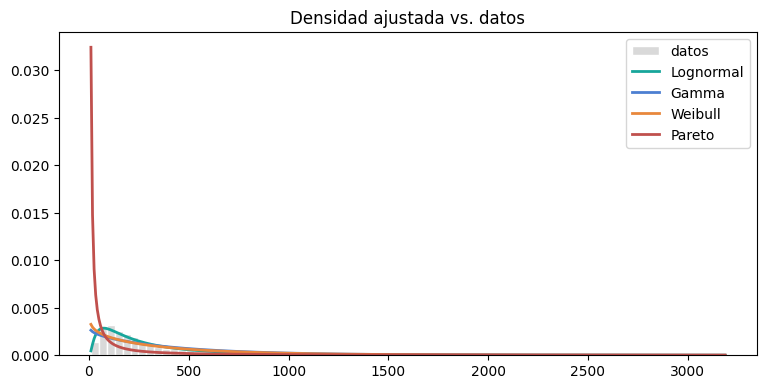

In [22]:
# ─── Densidad ajustada sobre el histograma ─────────────────────────────────
p99 = np.percentile(x, 99); grid = np.linspace(x.min(), p99, 400)
col = {"Lognormal": "#17A69B", "Gamma": "#4C7FD1", "Weibull": "#E8873C", "Pareto": "#C0504D"}
plt.hist(x, bins=80, density=True, range=(x.min(), p99), color="#d9d9d9", edgecolor="white", label="datos")
for nom, (d, pr) in ajustes.items():
    plt.plot(grid, d.pdf(grid, *pr), lw=2, color=col[nom], label=nom)
plt.title("Densidad ajustada vs. datos"); plt.legend(); plt.show()

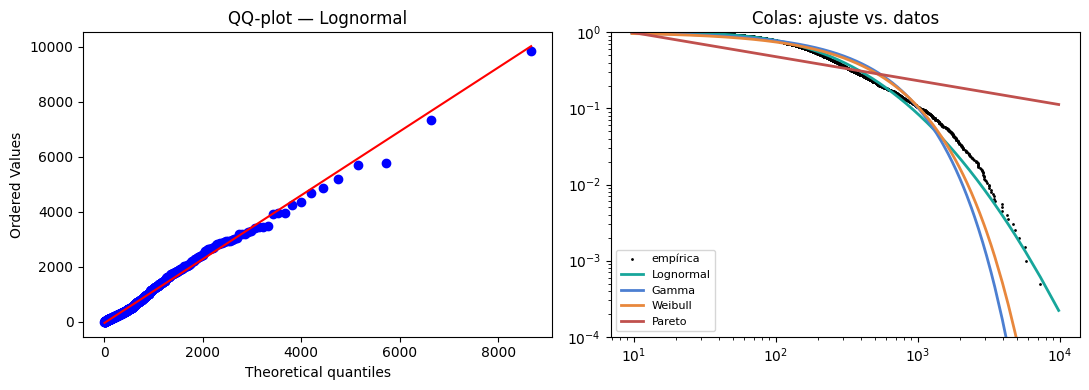

In [23]:
# ─── QQ-plot de la mejor + supervivencia de todas ──────────────────────────
dist, pr = ajustes[mejor]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(x, dist=dist, sparams=pr, plot=ax[0]); ax[0].set_title(f"QQ-plot — {mejor}")
ax[1].plot(xs, S_emp, ".", ms=2, color="black", label="empírica")
for nom, (d, p) in ajustes.items():
    ax[1].plot(xs, d.sf(xs, *p), lw=2, color=col[nom], label=nom)
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, 1)
ax[1].set_title("Colas: ajuste vs. datos"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
<a id='8'></a>
## 8. Qué cambia en la cola: VaR, TVaR y prima

La cola cambia el **precio**. Medimos el cuantil alto y la esperanza más allá de él:

$$VaR_p=F^{-1}(p)\qquad TVaR_p=E[X\mid X>VaR_p]$$

In [24]:
# ─── VaR y TVaR al 99% para dos distribuciones ─────────────────────────────
def var_tvar(nombre, p=0.99):
    d, pr = ajustes[nombre]; fr = d(*pr)
    var  = fr.ppf(p)
    tvar = fr.expect(lambda t: t, lb=var, conditional=True)   # E[X | X > VaR]
    return var, tvar

print(f"{'Distribución':<12}{'VaR99':>12}{'TVaR99':>12}")
for nom in [mejor, "Gamma"]:
    v, t = var_tvar(nom)
    print(f"{nom:<12}{v:>12,.0f}{t:>12,.0f}")
print("\nMisma cartera: la cola más pesada (lognormal) da VaR y TVaR más altos")
print("que una cola ligera (gamma). La distribución elegida mueve el precio de la cola.")

Distribución       VaR99      TVaR99
Lognormal          2,776       4,262
Gamma              2,069       2,530

Misma cartera: la cola más pesada (lognormal) da VaR y TVaR más altos
que una cola ligera (gamma). La distribución elegida mueve el precio de la cola.


### ✏️ Ejercicio 4 — el efecto en la prima

La prima pura con un **límite** $L$ (la aseguradora paga a lo más $L$ por siniestro) es la
**esperanza limitada** $E[\min(X,L)]$.

1. Con la distribución `mejor`, calcula $E[\min(X,L)]$ para $L=500$ y $L=1000$.
   *Pista:* `dist(*pr).expect(lambda t: np.minimum(t, L))`.
2. Repite con `Pareto` y compara: ¿cuál distribución hace más cara la cobertura al subir $L$?
3. Explica en 2 líneas por qué esto importa para el reaseguro.

In [28]:
# Tu código aquí 👇
#1 y 2
dist_mejor, pr_mejor = ajustes[mejor]
dist_pareto, pr_pareto = ajustes["Pareto"]

def e_limitada(dist, pr, L):
    return dist(*pr).expect(lambda t: np.minimum(t, L))
e_lognormal_500 = e_limitada(dist_mejor, pr_mejor, 500)
e_lognormal_1000 = e_limitada(dist_mejor, pr_mejor, 1000)
e_pareto_500 = e_limitada(dist_pareto, pr_pareto, 500)
e_pareto_1000 = e_limitada(dist_pareto, pr_pareto, 1000)

print("-----Lognormal (mejor)------")
print(f"L=500: {e_lognormal_500: .2f}")
print(f"L=1000: {e_lognormal_1000: .2f}")
print(f"Incremento al subir L de 500 a 100: +{e_lognormal_1000 - e_lognormal_500: .2f}")
print("-----Pareto------")
print(f"L=500: {e_pareto_500: .2f}")
print(f"L=1000: {e_pareto_1000: .2f}")
print(f"Incremento al subir L de 500 a 100: +{e_pareto_1000 - e_pareto_500: .2f}")

#¿Cuál es la distribución que hace más cara la cobertura al subir L?
print("Pareto hace más cara la cobertura al subir L")
print("Al aumentar el límite L de 500 a 1000, la prima de la Pareto sube mucho más drásticamente que la de la Lognormal.")

#3 Explicación al reaseguro
print("El reaseguro es un seguro para siniestros muy grandes. Si se usa una distribución con cola muy pesada como lo es la Pareto, implica que estos siniestros de grane escala ocurrirán muy seguido y esto hace que contratar al reasegurador salga más caro pues se asume que las pérdidas muy grandes son comunes.")

-----Lognormal (mejor)------
L=500:  266.96
L=1000:  338.75
Incremento al subir L de 500 a 100: + 71.79
-----Pareto------
L=500:  181.31
L=1000:  284.28
Incremento al subir L de 500 a 100: + 102.97
Pareto hace más cara la cobertura al subir L
Al aumentar el límite L de 500 a 1000, la prima de la Pareto sube mucho más drásticamente que la de la Lognormal.
El reaseguro es un seguro para siniestros muy grandes. Si se usa una distribución con cola muy pesada como lo es la Pareto, implica que estos siniestros de grane escala ocurrirán muy seguido y esto hace que contratar al reasegurador salga más caro pues se asume que las pérdidas muy grandes son comunes.


/usr/local/lib/python3.13/dist-packages/scipy/stats/_distn_infrastructure.py:3036: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  dub = integrate.quad(fun, d, ub, **kwds)[0]


---
<a id='9'></a>
## 9. Vistazo bayesiano

La máxima verosimilitud da un **punto**; pero los parámetros son inciertos. El enfoque bayesiano
los trata como aleatorios: $\pi(\theta\mid x)\propto f(x\mid\theta)\,\pi(\theta)$. Lo vemos con el
caso conjugado **Poisson–Gamma** (la base de la credibilidad).

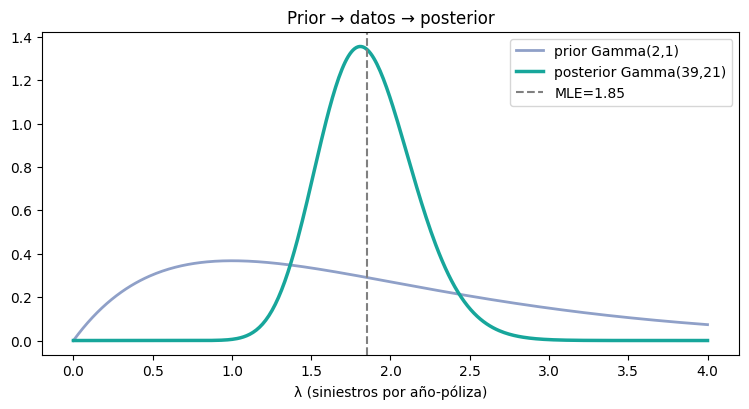

Media prior=2.00   MLE=1.85   Media posterior=1.86  (mezcla → credibilidad)


In [29]:
# ─── Prior → datos → posterior (Poisson–Gamma) ─────────────────────────────
a0, b0 = 2.0, 1.0                 # prior Gamma(forma, tasa) sobre λ
N_obs, E_obs = 37, 20.0           # 37 siniestros en 20 años-póliza de exposición
a1, b1 = a0 + N_obs, b0 + E_obs   # posterior conjugado

g = np.linspace(0, 4, 400)
plt.plot(g, stats.gamma(a0, scale=1/b0).pdf(g), color="#8FA0C8", lw=2, label=f"prior Gamma({a0:.0f},{b0:.0f})")
plt.plot(g, stats.gamma(a1, scale=1/b1).pdf(g), color="#17A69B", lw=2.5, label=f"posterior Gamma({a1:.0f},{b1:.0f})")
plt.axvline(N_obs/E_obs, ls="--", color="gray", label=f"MLE={N_obs/E_obs:.2f}")
plt.title("Prior → datos → posterior"); plt.xlabel("λ (siniestros por año-póliza)"); plt.legend(); plt.show()
print(f"Media prior={a0/b0:.2f}   MLE={N_obs/E_obs:.2f}   Media posterior={a1/b1:.2f}  (mezcla → credibilidad)")

### ✏️ Ejercicio 5 — el peso de los datos

1. Duplica la exposición y los siniestros (`N_obs=74`, `E_obs=40`) y vuelve a graficar el posterior.
2. ¿El posterior se pega más al MLE o al prior? ¿Por qué?

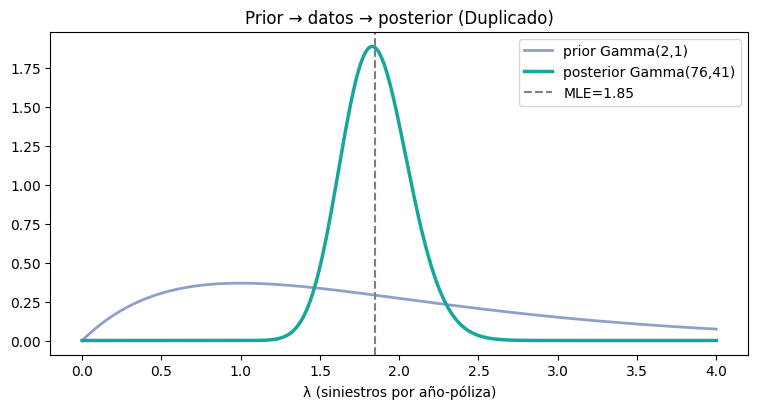

Media prior=2.00   MLE=1.85   Media posterior=1.85
Se pega más al MLE
Al tener más información y datos observados, la evidencia real pesa mucho más que la creencia inicial (prior). Entre más datos tengas, la estadística bayesiana se inclina casi por completo a lo que dicen los datos reales (MLE) pues la prior es lo que se creía antes de ver los datos 
Al duplicar la muestra, la curva del posterior se hace más alta y delgada, se concentra casi exactamente sobre la línea del MLE.
La cartera gana más credibilidad por sí misma.


In [32]:
# Tu código aquí 👇
#1
a0, b0 = 2.0, 1.0
N_obs, E_obs = 74, 40.0
a1, b1 = a0 + N_obs, b0 + E_obs

g = np.linspace(0, 4, 400)
plt.plot(g, stats.gamma(a0, scale=1/b0).pdf(g), color="#8FA0C8", lw=2, label=f"prior Gamma({a0:.0f},{b0:.0f})")
plt.plot(g, stats.gamma(a1, scale=1/b1).pdf(g), color="#17A69B", lw=2.5, label=f"posterior Gamma({a1:.0f},{b1:.0f})")
plt.axvline(N_obs/E_obs, ls="--", color="gray", label=f"MLE={N_obs/E_obs:.2f}")

plt.title("Prior → datos → posterior (Duplicado)")
plt.xlabel("λ (siniestros por año-póliza)")
plt.legend()
plt.show()
print(f"Media prior={a0/b0:.2f}   MLE={N_obs/E_obs:.2f}   Media posterior={a1/b1:.2f}")

#2
print("Se pega más al MLE")
print("Al tener más información y datos observados, la evidencia real pesa mucho más que la creencia inicial (prior). Entre más datos tengas, la estadística bayesiana se inclina casi por completo a lo que dicen los datos reales (MLE) pues la prior es lo que se creía antes de ver los datos ")
print("Al duplicar la muestra, la curva del posterior se hace más alta y delgada, se concentra casi exactamente sobre la línea del MLE.")
print("La cartera gana más credibilidad por sí misma.")

---
<a id='10'></a>
## 10. Cierre → Práctica A1

Con los datos de severidad de **tu ramo**:

1. Grafica la familia y su cola; ajusta las candidatas y arma la tabla de AIC.
2. Elige una distribución y **justifícala con la cola** (no solo con el AIC).
3. Reporta $E[X]$, $VaR_{99}$ y $TVaR_{99}$, y la prima pura con un límite $L$.
4. Escribe 3 líneas conectando tu elección con la nota técnica del producto.

> Súbelo a tu carpeta del repositorio en GitHub.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Sesión 1*

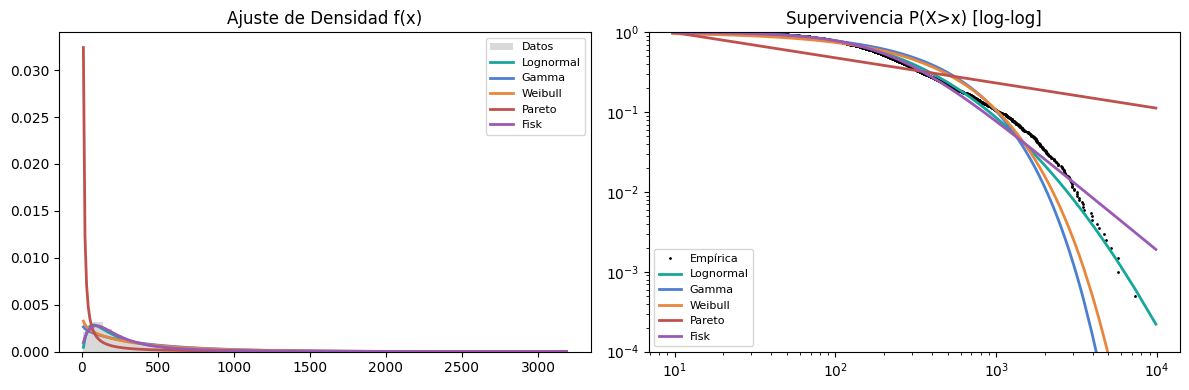

--- 1. TABLA DE AIC ---
Distribución     AIC
   Lognormal 27723.7
        Fisk 27751.0
     Weibull 28225.0
       Gamma 28283.1
      Pareto 30399.9
--- 2. Elige distribución y justifica con la cola no solo el AIC.---
Elegimos la Lognormal porque se pega a la cola empírica de los datos sin inflar la probabilidad de siniestros gigantes como Pareto ni subestimarla como Gamma.

--- 3. MÉTRICAS REPORTADAS ---
Distribución seleccionada : Lognormal
Esperanza E[X]            : $409.51
VaR (99%)                 : $2,776.09
TVaR (99%)                : $4,262.05
Prima limitada (L=1000)    : $338.75
---4. Elección conectando con la nota técnica.---
La Lognormal evita cobrar una prima exagerada al cliente, pero cubriendo bien los siniestros caros.
El TVaR (99%) nos dice exactamente cuánto dinero guardar en caja para resistir un año de siniestros desastrosos
La esperanza limitada E[min(X, 1000)] nos fija la base matemática para cobrar coberturas con tope y negociar el deducible con el reasegurador

In [36]:

candidatas = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto,
    "Fisk": stats.fisk
}
colores = {
    "Lognormal": "#17A69B",
    "Gamma": "#4C7FD1",
    "Weibull": "#E8873C",
    "Pareto": "#C0504D",
    "Fisk": "#9B59B6"
}
ajustes = {}
filas = []

for nom, dist in candidatas.items():
    pr = dist.fit(x, floc=0)
    ajustes[nom] = (dist, pr)
    # Cálculo de AIC
    log_lik = np.sum(dist.logpdf(x, *pr))
    k = len(pr)
    aic_val = 2 * k - 2 * log_lik
    filas.append({"Distribución": nom, "AIC": round(aic_val, 1)})

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
grid = np.linspace(x.min(), np.percentile(x, 99), 300)
xs = np.sort(x)
S_emp = 1.0 - np.arange(1, len(xs) + 1) / len(xs)

ax[0].hist(x, bins=50, density=True, range=(x.min(), np.percentile(x, 99)), color="#d9d9d9", label="Datos")
for nom, (dist, pr) in ajustes.items():
    ax[0].plot(grid, dist.pdf(grid, *pr), color=colores[nom], lw=2, label=nom)
ax[0].set_title("Ajuste de Densidad f(x)")
ax[0].legend(fontsize=8)

ax[1].plot(xs, S_emp, ".", ms=2, color="black", label="Empírica")
for nom, (dist, pr) in ajustes.items():
    ax[1].plot(xs, dist.sf(xs, *pr), color=colores[nom], lw=2, label=nom)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_ylim(1e-4, 1)
ax[1].set_title("Supervivencia P(X>x) [log-log]")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

tabla_aic = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
print("--- 1. TABLA DE AIC ---")
print(tabla_aic.to_string(index=False))

mejor_nombre = tabla_aic.iloc[0]["Distribución"]
dist_elegida, pr_elegida = ajustes[mejor_nombre]
fr = dist_elegida(*pr_elegida)

print("--- 2. Elige distribución y justifica con la cola no solo el AIC.---")
print("Elegimos la Lognormal porque se pega a la cola empírica de los datos sin inflar la probabilidad de siniestros gigantes como Pareto ni subestimarla como Gamma.")


L = 1000

esperanza = fr.mean()
var_99 = fr.ppf(0.99)
tvar_99 = fr.expect(lambda t: t, lb=var_99, conditional=True)
prima_limitada = fr.expect(lambda t: np.minimum(t, L))

print("\n--- 3. MÉTRICAS REPORTADAS ---")
print(f"Distribución seleccionada : {mejor_nombre}")
print(f"Esperanza E[X]            : ${esperanza:,.2f}")
print(f"VaR (99%)                 : ${var_99:,.2f}")
print(f"TVaR (99%)                : ${tvar_99:,.2f}")
print(f"Prima limitada (L={L})    : ${prima_limitada:,.2f}")

print("---4. Elección conectando con la nota técnica.---")
print("La Lognormal evita cobrar una prima exagerada al cliente, pero cubriendo bien los siniestros caros.")
print("El TVaR (99%) nos dice exactamente cuánto dinero guardar en caja para resistir un año de siniestros desastrosos")
print("La esperanza limitada E[min(X, 1000)] nos fija la base matemática para cobrar coberturas con tope y negociar el deducible con el reasegurador.")